In [ ]:
import numpy as np
import pandas as pd


In [5]:
df = pd.read_csv('food_delivery_orders_dataset.csv')
print(df.head())

  getorder_id customer_id restaurant_id driver_id      order_timestamp  \
0  ORD_000001   CUS_00001      RES_0008  DRV_0075  2025-10-05 15:54:00   
1  ORD_000002   CUS_00013      RES_0024  DRV_0131  2025-10-01 20:00:00   
2  ORD_000003   CUS_00049      RES_0013  DRV_0087  2025-10-07 18:24:00   
3  ORD_000004   CUS_00007      RES_0001  DRV_0177  2025-10-30 16:54:00   
4  ORD_000005   CUS_00325      RES_0029  DRV_0114  2025-10-15 18:34:00   

   order_date  order_hour day_of_week  is_weekend    city  ... traffic_level  \
0  2025-10-05          15      Sunday           1  City_C  ...        Medium   
1  2025-10-01          20   Wednesday           0  City_A  ...          High   
2  2025-10-07          18     Tuesday           0  City_C  ...          High   
3  2025-10-30          16    Thursday           0  City_A  ...           Low   
4  2025-10-15          18   Wednesday           0  City_B  ...        Medium   

   delivery_partner_experience_months delivery_partner_rating  \
0        

In [4]:
import pandas as pd


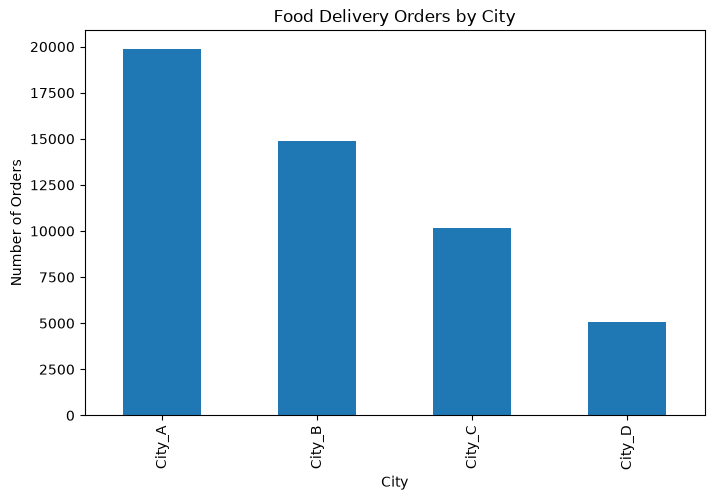

In [6]:
import matplotlib.pyplot as plt

city_orders = df["city"].value_counts()

plt.figure(figsize=(8, 5))
city_orders.plot(kind="bar")

plt.title("Food Delivery Orders by City")
plt.xlabel("City")
plt.ylabel("Number of Orders")

plt.show()

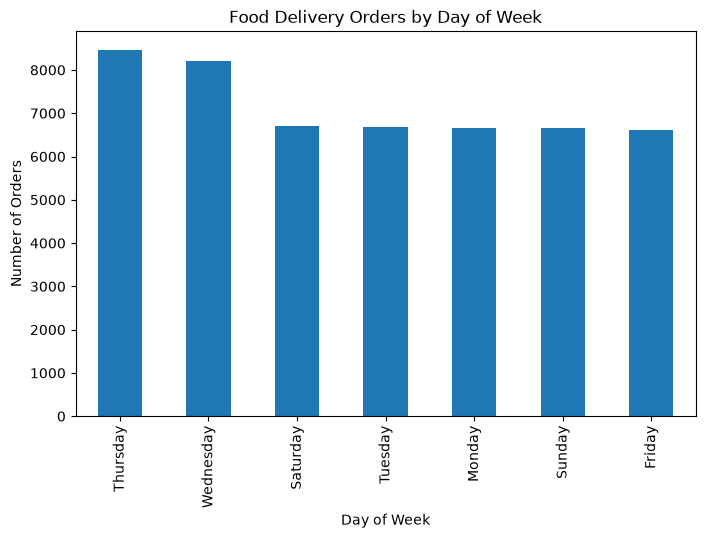

In [7]:
import matplotlib.pyplot as plt

day_orders = df["day_of_week"].value_counts()

plt.figure(figsize=(8, 5))
day_orders.plot(kind="bar")

plt.title("Food Delivery Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")

plt.show()

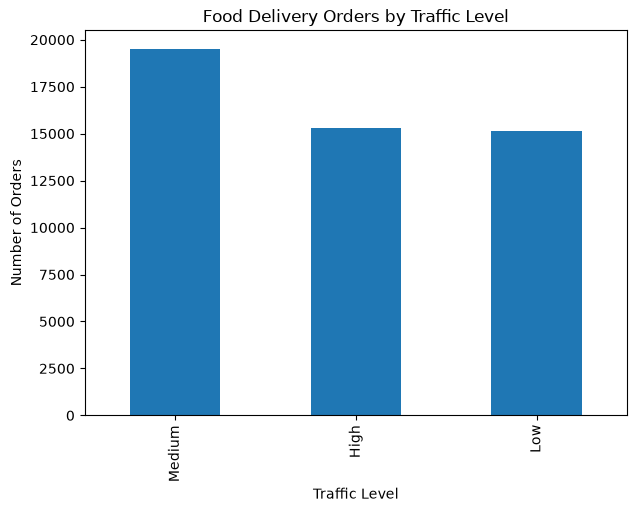

In [8]:
import matplotlib.pyplot as plt

traffic_orders = df["traffic_level"].value_counts()

plt.figure(figsize=(7, 5))
traffic_orders.plot(kind="bar")

plt.title("Food Delivery Orders by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Number of Orders")

plt.show()

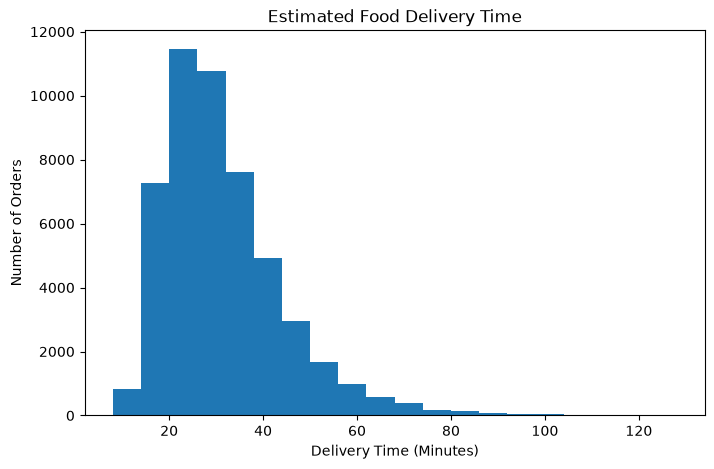

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["estimated_delivery_time_minutes"].dropna(), bins=20)

plt.title("Estimated Food Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Orders")

plt.show()

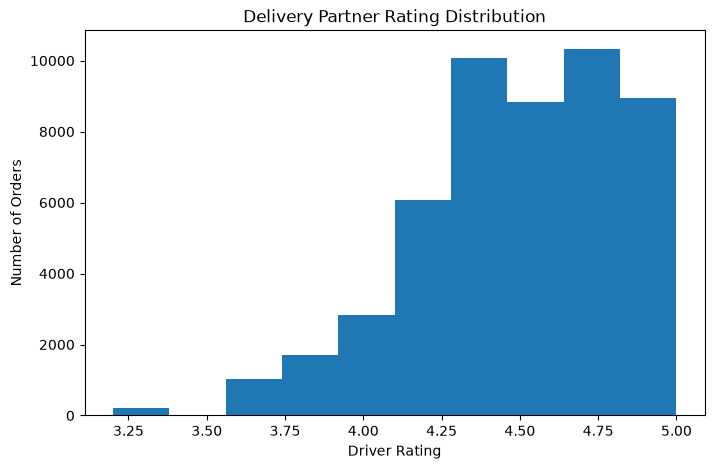

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["delivery_partner_rating"].dropna(), bins=10)

plt.title("Delivery Partner Rating Distribution")
plt.xlabel("Driver Rating")
plt.ylabel("Number of Orders")

plt.show()

In [12]:
print(df.columns.tolist())

['getorder_id', 'customer_id', 'restaurant_id', 'driver_id', 'order_timestamp', 'order_date', 'order_hour', 'day_of_week', 'is_weekend', 'city', 'delivery_area', 'customer_age', 'customer_type', 'restaurant_type', 'restaurant_primary_category', 'restaurant_rating', 'items_count', 'subtotal', 'discount_percent', 'tax_amount', 'service_fee', 'delivery_fee', 'order_total', 'payment_method', 'tip_amount', 'distance_km', 'weather', 'traffic_level', 'delivery_partner_experience_months', 'delivery_partner_rating', 'restaurant_preparation_time_minutes', 'estimated_delivery_time_minutes', 'actual_delivery_time_minutes', 'late_delivery', 'order_status', 'cancellation_reason', 'customer_rating']


In [13]:
print(df.dtypes)

getorder_id                                str
customer_id                                str
restaurant_id                              str
driver_id                                  str
order_timestamp                            str
order_date                                 str
order_hour                               int64
day_of_week                                str
is_weekend                               int64
city                                       str
delivery_area                              str
customer_age                             int64
customer_type                              str
restaurant_type                            str
restaurant_primary_category                str
restaurant_rating                      float64
items_count                              int64
subtotal                               float64
discount_percent                         int64
tax_amount                             float64
service_fee                            float64
delivery_fee 

In [14]:
print(df.isnull().sum())

getorder_id                                0
customer_id                                0
restaurant_id                              0
driver_id                                  0
order_timestamp                            0
order_date                                 0
order_hour                                 0
day_of_week                                0
is_weekend                                 0
city                                       0
delivery_area                              0
customer_age                               0
customer_type                              0
restaurant_type                            0
restaurant_primary_category                0
restaurant_rating                          0
items_count                                0
subtotal                                   0
discount_percent                           0
tax_amount                                 0
service_fee                                0
delivery_fee                               0
order_tota

In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 50000
Columns: 37


In [18]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 37 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   getorder_id                          50000 non-null  str    
 1   customer_id                          50000 non-null  str    
 2   restaurant_id                        50000 non-null  str    
 3   driver_id                            50000 non-null  str    
 4   order_timestamp                      50000 non-null  str    
 5   order_date                           50000 non-null  str    
 6   order_hour                           50000 non-null  int64  
 7   day_of_week                          50000 non-null  str    
 8   is_weekend                           50000 non-null  int64  
 9   city                                 50000 non-null  str    
 10  delivery_area                        50000 non-null  str    
 11  customer_age                         50

In [19]:
df["order_timestamp"] = pd.to_datetime(df["order_timestamp"])
df["order_date"] = pd.to_datetime(df["order_date"])

print(df[["order_timestamp", "order_date"]].dtypes)

order_timestamp    datetime64[us]
order_date         datetime64[us]
dtype: object


In [20]:
# Step 10B - Order status
print(df["order_status"].value_counts())

# Step 10C - Fill missing values
df["tip_amount"] = df["tip_amount"].fillna(0)
df["customer_rating"] = df["customer_rating"].fillna(df["customer_rating"].median())
df["cancellation_reason"] = df["cancellation_reason"].fillna("Not Cancelled")

# Step 10D - Create useful columns
df["month"] = df["order_date"].dt.month
df["date"] = df["order_date"].dt.date

# Step 10E - Delivery delay
df["delivery_delay"] = (
    df["actual_delivery_time_minutes"]
    - df["estimated_delivery_time_minutes"]
)

print("Data preparation completed!")

order_status
Completed    49132
Cancelled      868
Name: count, dtype: int64
Data preparation completed!


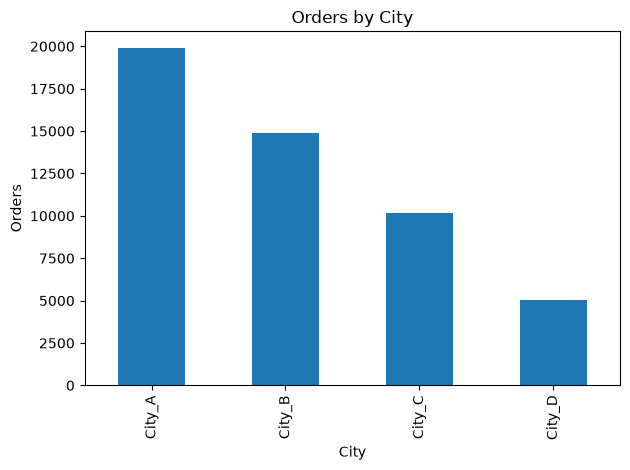

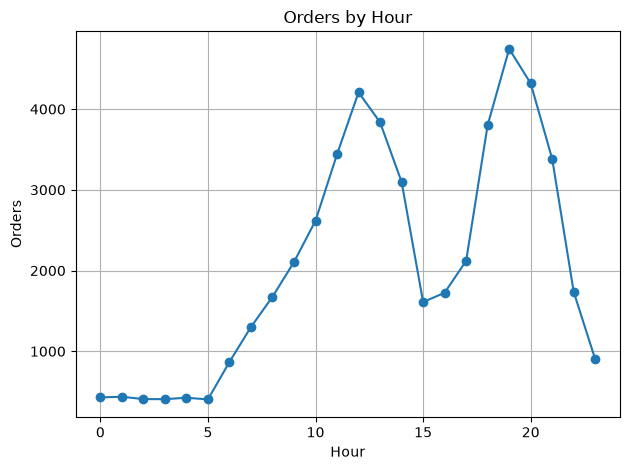

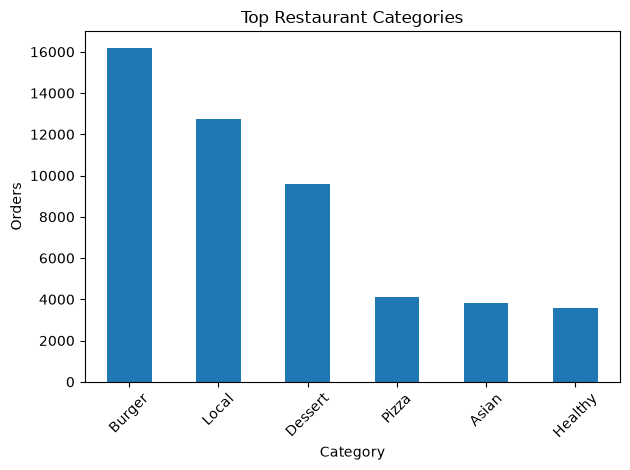

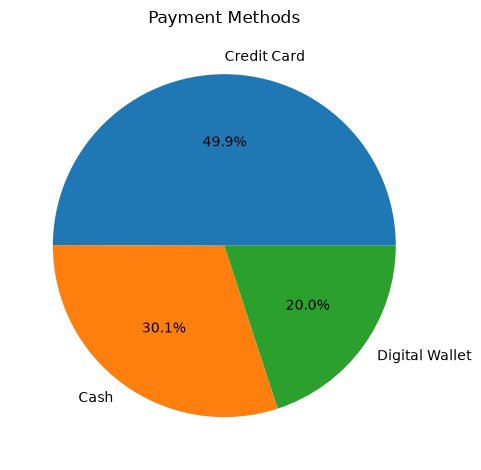

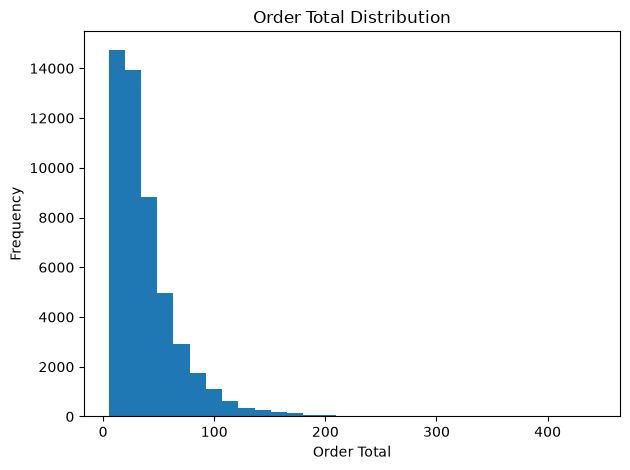

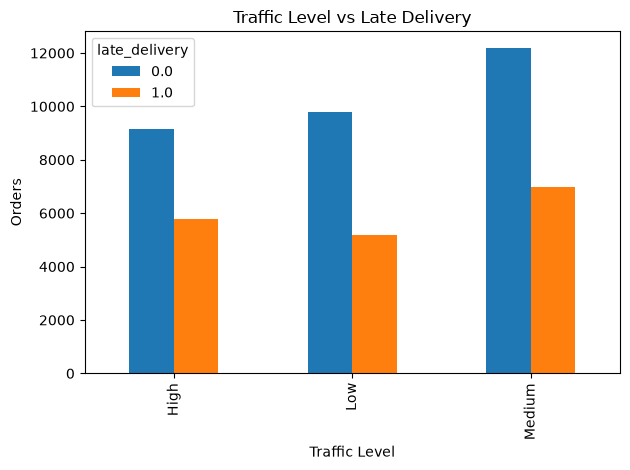

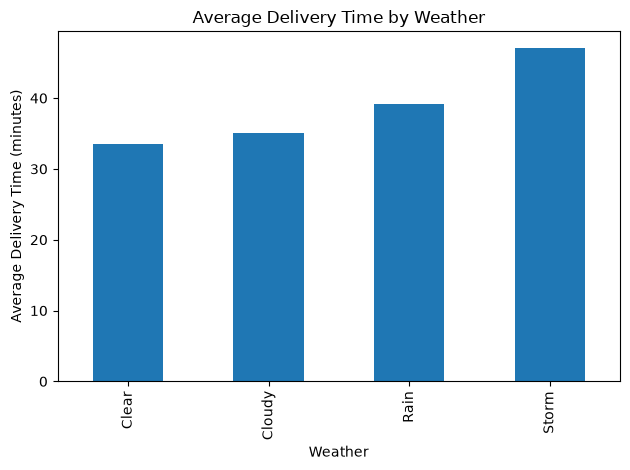

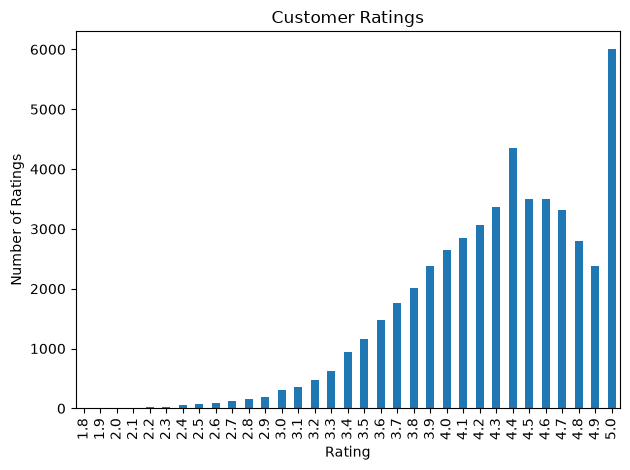

In [21]:
import matplotlib.pyplot as plt

# 1. Orders by city
df["city"].value_counts().plot(kind="bar")
plt.title("Orders by City")
plt.xlabel("City")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

# 2. Orders by hour
df["order_hour"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.grid()
plt.tight_layout()
plt.show()

# 3. Orders by restaurant category
df["restaurant_primary_category"].value_counts().head(10).plot(kind="bar")
plt.title("Top Restaurant Categories")
plt.xlabel("Category")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Payment methods
df["payment_method"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Methods")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 5. Order total distribution
df["order_total"].plot(kind="hist", bins=30)
plt.title("Order Total Distribution")
plt.xlabel("Order Total")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 6. Traffic vs late delivery
pd.crosstab(
    df["traffic_level"],
    df["late_delivery"]
).plot(kind="bar")
plt.title("Traffic Level vs Late Delivery")
plt.xlabel("Traffic Level")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

# 7. Weather vs delivery time
df.groupby("weather")["actual_delivery_time_minutes"].mean().plot(kind="bar")
plt.title("Average Delivery Time by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (minutes)")
plt.tight_layout()
plt.show()

# 8. Customer ratings
df["customer_rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.show()

In [22]:
print("========== FOOD DELIVERY SUMMARY ==========")

print("Total Orders:", len(df))
print("Total Revenue:", round(df["order_total"].sum(), 2))
print("Average Order Value:", round(df["order_total"].mean(), 2))
print("Average Delivery Time:",
      round(df["actual_delivery_time_minutes"].mean(), 2), "minutes")
print("Late Delivery Rate:",
      round(df["late_delivery"].mean() * 100, 2), "%")
print("Average Customer Rating:",
      round(df["customer_rating"].mean(), 2))

print("\nTop City:", df["city"].value_counts().idxmax())
print("Top Restaurant Category:",
      df["restaurant_primary_category"].value_counts().idxmax())
print("Most Used Payment Method:",
      df["payment_method"].value_counts().idxmax())

========== FOOD DELIVERY SUMMARY ==========
Total Orders: 50000
Total Revenue: 1908475.05
Average Order Value: 38.17
Average Delivery Time: 35.15 minutes
Late Delivery Rate: 36.57 %
Average Customer Rating: 4.3

Top City: City_A
Top Restaurant Category: Burger
Most Used Payment Method: Credit Card
